# Premier essaie de génération d'images

In [111]:
# Suppression des warnings FutureWarning
import warnings  # Gère les warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd  # Manipulation de données tabulaires
import numpy as np  # Calcul scientifique et manipulation de matrices
import os  # Interaction avec le système de fichiers
from os.path import isfile, join  # Fonctions de gestion des chemins de fichiers
import sys  # Interaction avec l'interpréteur Python
import random  # Génération de nombres aléatoiresr
import zipfile  # Manipulation d'archives zip
from scipy.stats import norm, entropy # Statistiques sur les données

# Librairie d'affichage
import matplotlib.pyplot as plt  # Visualisation de données
from matplotlib.offsetbox import OffsetImage, AnnotationBbox  # Visualisation de données
from PIL import Image, ImageDraw  # Traitement d'images avec Pillow

# Bibliothèque scikit-learn
from sklearn.decomposition import PCA  # Réduction de dimension
from sklearn.manifold import TSNE  # Visualisation de données en dimension réduite

# TensorFlow et Keras
import tensorflow as tf  # API principale de TensorFlow
from tensorflow.keras.losses import mse  # Perte par erreur quadratique moyenne
from keras import layers, models, optimizers  # Création et gestion des modèles
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Générateur
from keras.preprocessing.image import img_to_array, load_img, array_to_img  # Préparation et transformation des images
from keras.callbacks import ModelCheckpoint, EarlyStopping  # Gestion des callbacks pour l'entraînement
from keras.layers import (Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape,
                           Lambda, Activation, BatchNormalization, LeakyReLU, Dropout,
                           MaxPooling2D, UpSampling2D)  # Différentes couches pour les modèles CNN
from keras.optimizers import Adam  # Optimiseur Adam
from keras.models import Model, load_model  # Définition et chargement des modèles Keras
from keras.layers import LeakyReLU  # Activation LeakyReLU
import tensorflow.keras.backend as K # Import des opérations bas niveau de Keras

In [72]:
# Définition du répertoire cible
model_dir = "./Data_humanface_cat_without_caption_1000/"

# Création du répertoire s'il n'existe pas
os.makedirs(model_dir, exist_ok=True)

zip_file = "Data_humanface_cat_without_caption_1000.zip"

!wget https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_1000.zip


# Extraction du fichier ZIP
with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(model_dir)

# Suppression du fichier ZIP après extraction pour économiser de l'espace
os.remove(zip_file)

--2026-05-01 23:12:48--  https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_1000.zip
Resolving www.lirmm.fr (www.lirmm.fr)... 193.49.104.251
Connecting to www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42306490 (40M) [application/zip]
Saving to: ‘Data_humanface_cat_without_caption_1000.zip’

Data_humanface_cat_ 100%[===================>]  40.35M   736KB/s    in 33s     

2026-05-01 23:13:22 (1.23 MB/s) - ‘Data_humanface_cat_without_caption_1000.zip’ saved [42306490/42306490]



In [ ]:
##affichage des images 

Nombre d'images dans Data_humanface_cat_without_caption_1000/images/cat : 1000
Format (shape) des images : (256, 256, 3)


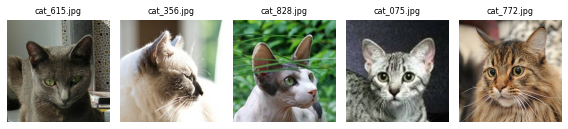

In [83]:
# Répertoire contenant les images
src_dir = "Data_humanface_cat_without_caption_1000/images"
image_dir = os.path.join(src_dir, "cat")

files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

print("Nombre d'images dans", image_dir, ":", len(files))

if files:
    with Image.open(os.path.join(image_dir, files[0])) as img:
        shape = img.size[::-1] + (3,)  # (height, width, 3)
        print("Format (shape) des images :", shape)


# Tirage de 5 images aléatoires
random_files = random.sample(files, 5)

# Affichage
plt.figure(figsize=(8, 2))
for i, fname in enumerate(random_files):
    img_path = os.path.join(image_dir, fname)
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(fname, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 512             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur

# Génération des données normalisées (valeurs entre 0 et 1)
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=src_dir,
    classes=["cat"],  # Le sous-dossier contenant toutes les images
    target_size=image_size[:2],  # Redimension à 128x128
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input'  # Autoencodeur : entrée = sortie
)

Found 1000 images belonging to 1 classes.


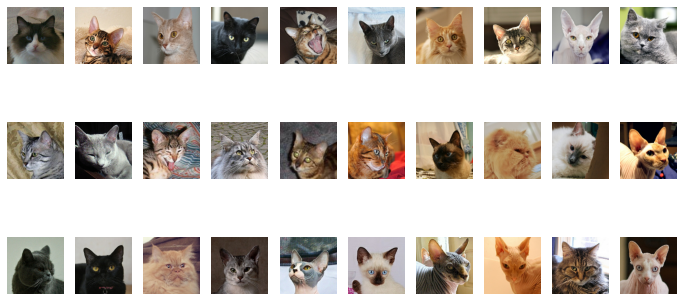

In [85]:
# Obtention du premier batch d'images générées
data_batch = next(data_flow)

# Affichage des 30 premières images du batch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 10, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(data_batch[0][i])
    ax.axis('off')
plt.show()

In [112]:
def build_encoder(input_dim, output_dim):
    tf.keras.backend.clear_session()

    encoder_input = Input(shape=input_dim, name='encoder_input')
    x = encoder_input

    x = Conv2D(32, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_1')(x)
    x = LeakyReLU(name='encoder_act_1')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_2')(x)
    x = LeakyReLU(name='encoder_act_2')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_3')(x)
    x = LeakyReLU(name='encoder_act_3')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_4')(x)
    x = LeakyReLU(name='encoder_act_4')(x)

    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = Flatten()(x)
    encoder_output = Dense(output_dim, name='encoder_output')(x)

    encoder = Model(encoder_input, encoder_output, name='encoder')
    return encoder_input, encoder_output, shape_before_flattening, encoder

def build_decoder(input_dim, shape_before_flattening):
    # Entrée du décodeur (vecteur latent)
    decoder_input = Input(shape=(input_dim,), name='decoder_input')

    # Projeter dans un tenseur de même forme qu'avant le Flatten de l'encodeur
    x = Dense(np.prod(shape_before_flattening))(decoder_input)
    x = Reshape(shape_before_flattening)(x)

    # Couches de déconvolution (effet miroir de l'encodeur)
    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_1')(x)
    x = LeakyReLU(name='decoder_act_1')(x)

    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_2')(x)
    x = LeakyReLU(name='decoder_act_2')(x)

    x = Conv2DTranspose(32, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_3')(x)
    x = LeakyReLU(name='decoder_act_3')(x)

    x = Conv2DTranspose(3, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_4')(x)
    decoder_output = Activation('sigmoid', name='decoder_output')(x)

    decoder = Model(decoder_input, decoder_output, name='decoder')
    return decoder_input, decoder_output, decoder

In [87]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 512             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur

# Création de l'encodeur avec les dimensions d'entrée et de sortie spécifiées
encoder_input, encoder_output, shape_before_flattening, encoder = build_encoder(
    input_dim=image_size,
    output_dim=latent_dim
)

# Création du décodeur en utilisant la dimension de l'espace latent
# et le shape  avant le flattening
decoder_input, decoder_output, decoder = build_decoder(
    input_dim=latent_dim,
    shape_before_flattening=shape_before_flattening
)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,648 (3.48 MB)

 Trainable params: 912,648 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# L'entrée du modèle autoencodeur est celle de l'encodeur
autoencoder_input = encoder_input

# La sortie est obtenue en appliquant le décodeur à la sortie de l'encodeur
autoencoder_output = decoder(encoder_output)

# Création du modèle autoencodeur complet (encodeur + décodeur)
autoencoder = Model(autoencoder_input, autoencoder_output, name='autoencoder')

# Affichage de la structure du modèle
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       916,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829,131 (6.98 MB)

 Trainable params: 1,829,131 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Génération des données normalisées (valeurs entre 0 et 1)
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # Le sous-dossier contenant toutes les images
    target_size=image_size[:2],  # Redimension à 128x128
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input'  # Autoencodeur : entrée = sortie
)

Found 1000 images belonging to 1 classes.


Espace latent

In [115]:
def visualize_latent_space(encoder_model, images, num_images=100,
                           image_size=(28, 28), zoom=0.6):
    """
    Visualise la répartition de l'espace latent en utilisant t-SNE
    et affiche des vignettes d'images.

    Paramètres :
    -----------
    encoder_model : Model
        Le modèle d'encodeur (autoencodeur ou VAE) à utiliser pour obtenir
        les vecteurs latents.
    images : array-like
        Batch d'images d'entrée pour la visualisation.
    num_images : int, optional
        Nombre d'images à utiliser pour la visualisation (par défaut 100).
    image_size : tuple, optional
        Taille des vignettes d'image à afficher (par défaut (28, 28)).
    zoom : float, optional
        Facteur de zoom pour les vignettes d'image (par défaut 0.6).
    """
    # Limite le nombre d'images à `num_images`
    images = images[:num_images]

    # Génère les vecteurs latents avec l'encodeur
    latent_vectors = encoder_model.predict(images)
    if isinstance(latent_vectors, list):
        latent_vectors = latent_vectors[0]

    # Aplatit les vecteurs latents s'ils ont plus de 2 dimensions
    if latent_vectors.ndim > 2:
        latent_vectors = latent_vectors.reshape((latent_vectors.shape[0], -1))

    # Réduction de dimension avec t-SNE pour projeter en 2D
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latent_vectors)

    plt.figure(figsize=(15, 12))
    ax = plt.gca()

    # Affichage des images dans l'espace t-SNE avec AnnotationBbox
    for i, (x, y) in enumerate(latent_2d):
        # Conversion de l'image en vignette
        thumbnail = array_to_img(images[i])
        thumbnail = thumbnail.resize(image_size)
        imagebox = OffsetImage(thumbnail, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)

    all_x, all_y = latent_2d[:, 0], latent_2d[:, 1]
    ax.set_xlim(all_x.min() - 5, all_x.max() + 5)
    ax.set_ylim(all_y.min() - 5, all_y.max() + 5)

    plt.title("Répartition des images dans l'espace latent")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

    ax.grid(False)
    plt.show()

In [123]:
#my guess is we need this before?
# Définition des hyperparamètres
epochs = 150
model_name = "catmodeltrain.keras"
model_path = os.path.join(model_dir, model_name)

# Compilation du modèle autoencodeur
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Générateur principal avec normalisation  et séparation train/validation
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur pour les données d'entraînement
train_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # le sous-dossier contenant toutes les images
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input',
    subset='training'
)

# Générateur pour les données de validation
val_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=False,
    seed=42,
    class_mode='input',
    subset='validation'
)


# Entraînement du modèle autoencodeur
#autoencoder = train_autoencoder_from_generator(
   # model=autoencoder,
    #train_gen=train_flow,
    #val_gen=val_flow,
    #model_path=model_path,
    #epochs=epochs,
    #patience=5
#)

Found 800 images belonging to 1 classes.
Found 200 images belonging to 1 classes.


In [124]:
# Chemin vers le modèle entraîné
model_path = os.path.join(model_dir, "catmodeltrain.keras")

# Chargement du modèle
autoencoder = load_model(model_path)

# Récupération du premier lot d'images
example_batch = next(data_flow)

# Extraction des images
example_batch = example_batch[0]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


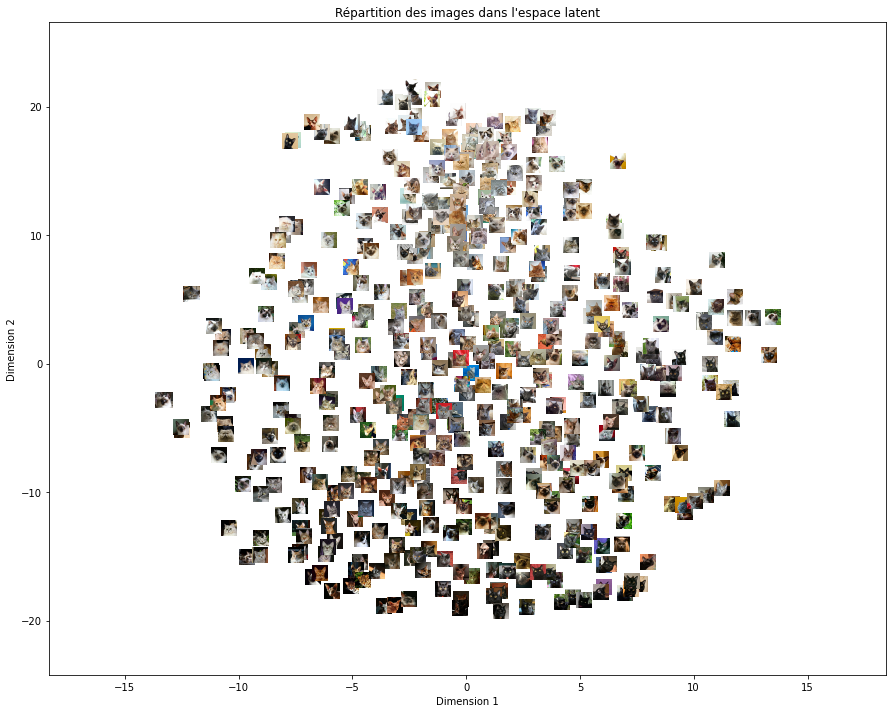

In [121]:
# Visualisation de l'espace latent avec les vignettes
visualize_latent_space(
    encoder_model=encoder,
    images=example_batch,
    num_images=batch_size,
    image_size=(32, 32),
    zoom=0.5
)